## Классная работа

In [20]:
from torch import nn
import torch
import torch.optim as optim
import torch.utils.data as data

from torchvision import models

import json
import os
from PIL import Image

from tqdm import tqdm

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
class DogDataset(data.Dataset):
  def __init__(self, path, train=True, transforms=None):
    self.path = os.path.join(path, "train" if train else "test")
    self.transforms = transforms

    with open(os.path.join(self.path, "format.json"), 'r') as file:
      self.format = json.load(file)

    self.files = []
    self.length = 0
    self.targets = torch.eye(10)

    for dir, target in self.format.items():
      dir_path = os.path.join(self.path, dir)
      self.length += len(os.listdir(dir_path))
      list_files = os.listdir(dir_path)
      self.files.extend(map(lambda x: (os.path.join(dir_path, x), target), list_files))
  def __getitem__(self, index):
    path_file, tg = self.files[index]
    t = self.targets[tg]
    img = Image.open(path_file)

    if self.transforms:
      img = self.transforms(img)

    return img, t

  def __len__(self):
    return self.length

In [53]:
resnet_weights = models.ResNet50_Weights.DEFAULT
transforms = resnet_weights.transforms()

In [54]:
model = models.resnet50(weights = resnet_weights)
model.requires_grad_(False);

In [55]:
model.fc = nn.Linear(512*4, 10)
model.fc.requires_grad_(True)

Linear(in_features=2048, out_features=10, bias=True)

In [31]:
d_train = DogDataset("/content/drive/MyDrive/Colab Notebooks/dl_selfedu_cource/datasets/dogs", train=True, transforms=transforms)
train_data = data.DataLoader(d_train, shuffle=True, batch_size=32)

In [32]:
d_test = DogDataset("/content/drive/MyDrive/Colab Notebooks/dl_selfedu_cource/datasets/dogs", train=False, transforms=transforms)
test_data = data.DataLoader(d_test, shuffle=False, batch_size=50)

In [56]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 3
model.train();

In [57]:
model = model.to(device)

In [58]:
for _e in range(epochs):
  loss_mean = 0
  lm_count = 0

  train_tqdm = tqdm(train_data, leave=True)
  for x_train, y_train in train_tqdm:
    x_train, y_train = x_train.to(device), y_train.to(device)
    y_pred = model(x_train)
    loss = loss_func(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    lm_count += 1
    loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
    train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")

Epoch [3/3], loss_mean=0.350: 100%|██████████| 51/51 [00:17<00:00,  2.84it/s]


In [59]:
st = model.state_dict()
torch.save(st, "/content/drive/MyDrive/Colab Notebooks/dl_selfedu_cource/cnn/models/resnet50_transfer_learning_dogs.tar")

In [60]:
# тестирование обученной НС
Q = 0
P = 0
count = 0
model.eval()

test_tqdm = tqdm(test_data, leave=True)
for x_test, y_test in test_tqdm:
    with torch.no_grad():
        x_test, y_test = x_test.to(device), y_test.to(device)
        p = model(x_test)
        p2 = torch.argmax(p, dim=1)
        y = torch.argmax(y_test, dim=1)
        P += torch.sum(p2 == y).item()
        Q += loss_func(p, y_test).item()
        count += 1

Q /= count
P /= len(d_test)
print()
print(Q)
print(P)

100%|██████████| 7/7 [00:03<00:00,  1.93it/s]


0.3205758886677878
0.9463722397476341


## Домашняя работа

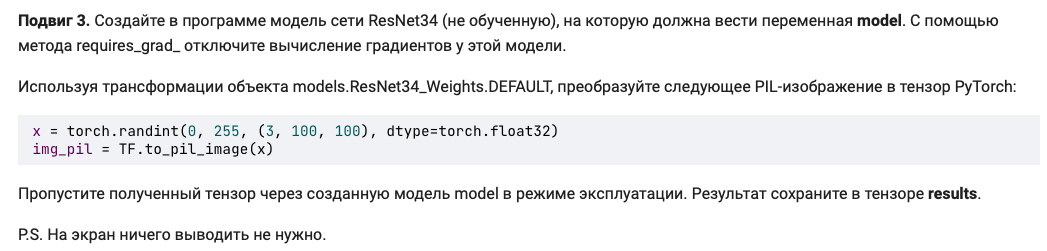

In [38]:
import torch
from torchvision import models
import torchvision.transforms.functional as TF

# тензор x и img_pil в программе не менять
x = torch.randint(0, 255, (3, 100, 100), dtype=torch.float32)
img_pil = TF.to_pil_image(x)

# здесь продолжайте программу
resnet_weights = models.ResNet34_Weights.DEFAULT
model = models.resnet34()
model.requires_grad_(False)
model.eval()

transforms = resnet_weights.transforms()
img = transforms(img_pil)

results = model(img.unsqueeze(0))

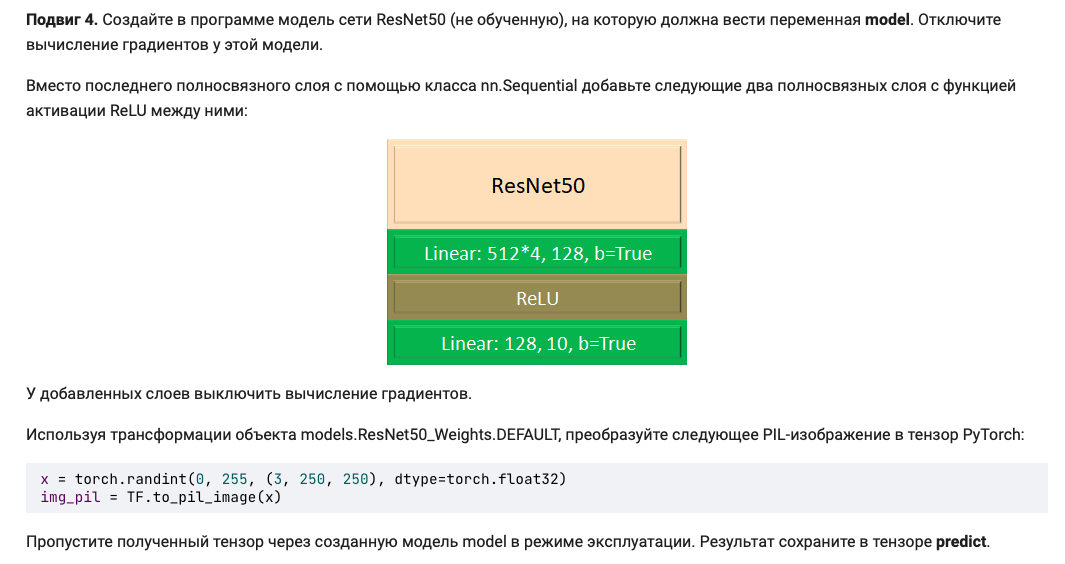

In [61]:
import torch
import torch.nn as nn
from torchvision import models
import torchvision.transforms.functional as TF

# тензор x и img_pil в программе не менять
x = torch.randint(0, 255, (3, 250, 250), dtype=torch.float32)
img_pil = TF.to_pil_image(x)

# здесь продолжайте программу
model = models.resnet50()
model.requires_grad_(False)

model.fc = nn.Sequential(
    nn.Linear(512*4, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model.fc.requires_grad_(False)

weights = models.ResNet50_Weights.DEFAULT
tfs = weights.transforms()

img = transforms(img_pil)
predict = model(img.unsqueeze(0))

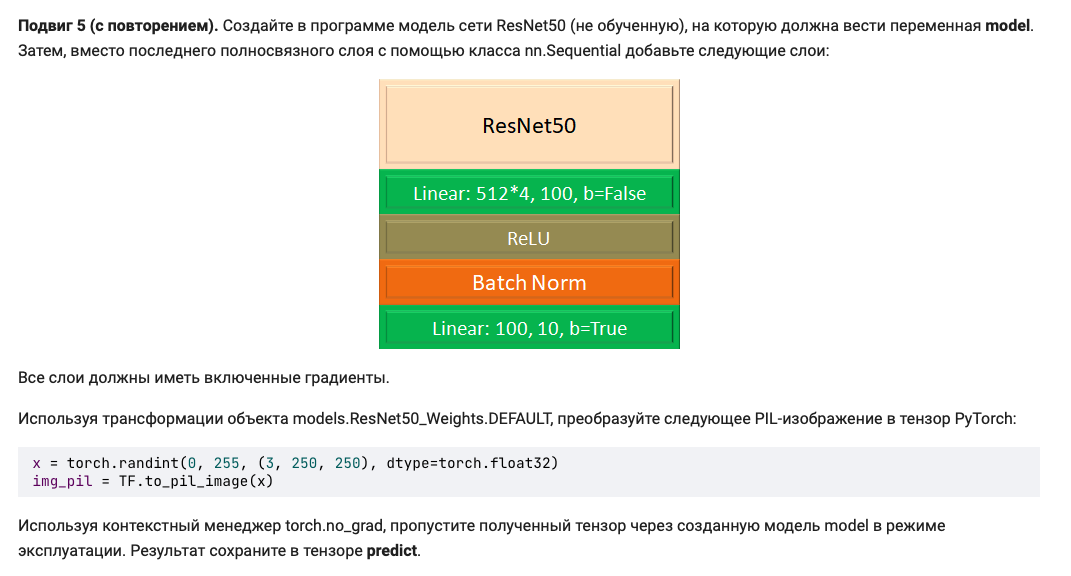

In [62]:
import torch
import torch.nn as nn
from torchvision import models
import torchvision.transforms.functional as TF

# тензор x и img_pil в программе не менять
x = torch.randint(0, 255, (3, 250, 250), dtype=torch.float32)
img_pil = TF.to_pil_image(x)

# здесь продолжайте программу
model = models.resnet50()
model.fc = nn.Sequential(
    nn.Linear(512*4, 100, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(100),
    nn.Linear(100, 10)
)
model.requires_grad_(True)
model.eval()

tfs = models.ResNet50_Weights.DEFAULT.transforms()
img = tfs(img_pil)

with torch.no_grad():
  predict = model(img.unsqueeze(0))


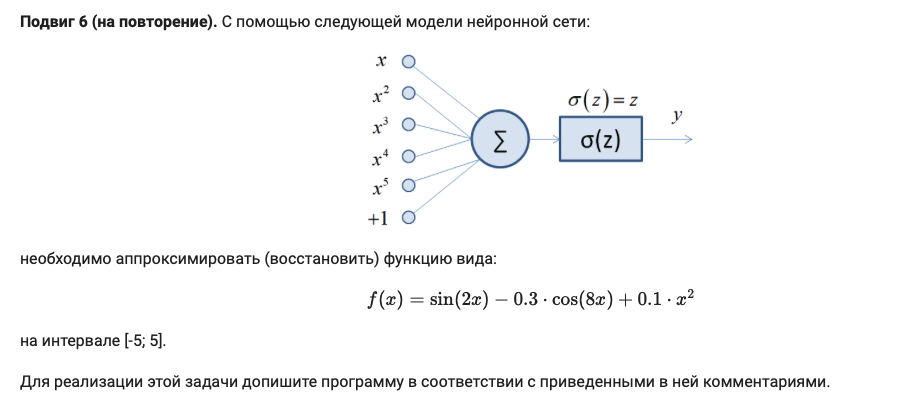

In [77]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

class FuncModel(nn.Module):
    def __init__(self):
        super().__init__()
        # модель однослойной полносвязной нейронной сети:
        # 1-й слой: число входов 5 (x, x^2, x^3, x^4, x^5), число нейронов 1
        self.layer = nn.Linear(5, 1)

    def forward(self, x):
        x.unsqueeze_(-1)
        xx = torch.cat([x, x ** 2, x ** 3, x ** 4, x ** 5], dim=1)
        y = self.layer(xx)
        return y


torch.manual_seed(1)

model = FuncModel() # создать модель FuncModel

epochs = 20 # число эпох обучения
batch_size = 16 # размер батча

# данные обучающей выборки (значения функции)
data_x = torch.arange(-5, 5, 0.05) #тензоры data_x, data_y не менять
data_y = torch.sin(2 * data_x) - 0.3 * torch.cos(8 * data_x) + 0.1 * data_x ** 2

ds = data.TensorDataset(data_x, data_y) # создание dataset
d_train, d_val = data.random_split(ds, [0.7, 0.3]) # разделить ds на две части в пропорции: 70% на 30%
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True) # создать объект класса DataLoader для d_train с размером пакетов batch_size и перемешиванием образов выборки
train_data_val = data.DataLoader(d_val, batch_size=batch_size, shuffle=False) # создать объект класса DataLoader для d_val с размером пакетов batch_size и без перемешивания образов выборки

optimizer = optim.RMSprop(params=model.parameters(), lr=0.01) # создать оптимизатор RMSprop для обучения модели с шагом обучения 0.01
loss_func = nn.MSELoss() # создать функцию потерь с помощью класса MSELoss

loss_lst_val = []  # список значений потерь при валидации
loss_lst = []  # список значений потерь при обучении

for _e in range(epochs):
    # перевести модель в режим обучения
    model.train()
    loss_mean = 0 # вспомогательные переменные для вычисления среднего значения потерь при обучении
    lm_count = 0

    for x_train, y_train in train_data:
        predict = model(x_train) # вычислить прогноз модели для данных x_train
        loss = loss_func(predict.squeeze(), y_train.squeeze()) # вычислить значение функции потерь

        # сделать один шаг градиентного спуска для корректировки параметров модели
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # вычисление среднего значения функции потерь по всей выборке
        lm_count += 1
        loss_mean = 1 / lm_count * loss.item() + (1 - 1 / lm_count) * loss_mean

    # валидация модели
    # перевести модель в режим эксплуатации
    model.eval()
    Q_val = 0
    count_val = 0

    for x_val, y_val in train_data_val:
        with torch.no_grad():
            # для x_val, y_val вычислить потери с помощью функции loss_func
            pred = model(x_val)
            loss = loss_func(pred.squeeze(), y_val)

            Q_val += loss
            count_val += 1

    # сохранить средние потери, вычисленные по выборке валидации, в переменной Q_val
    Q_val /= count_val

    loss_lst.append(loss_mean)
    loss_lst_val.append(Q_val)

# перевести модель в режим эксплуатации
model.eval()
# выполнить прогноз модели по всем данным выборки (ds.data)
all_feat,  all_targets = ds.tensors
pred = model(all_feat)
Q = loss_func(pred.squeeze(), all_targets).item() # вычислить потери с помощью loss_func по всем данным выборки ds; значение Q сохранить в виде вещественного числа